# Multiple inputs single objective

### this notebook is made to plot an example of Bayesian optimization using two inputs and one objective. 

## add the main repository to the path

This is made for running the code while it has not been installed, it should be removed when the installer would work

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [2]:
# library
import matplotlib.pyplot as plt
import torch

# project
from laplace_opt.post_analysis.postAnalysis import PostAnalysis
from tests.test_function.target_function import target_function

In [ ]:
folder = "data/2i_1o_not_noisy_missed/"
file = "model_observations_000003.pt"

pa = PostAnalysis(path=folder + file)


            Date: 2026-06-08 18:08:33
            Observations: 65
            Inputs: 2
            Objectives: 1
            Initial observations: 16
            Repeats: 1
            Steps: 50
            Description: 
            


## get the init and optimization points

In [4]:
ctx_init = pa.get_initial_context()
ctx = pa.get_final_context()

Context created.
Observation added: x=[3.7012863159179688, 5.110287666320801], y=[-0.5300626754760742], shot_number=392
Observation added: x=[4.945160388946533, -1.5545367002487183], y=[0.001659519039094448], shot_number=393
Observation added: x=[9.408039093017578, 8.348128318786621], y=[-0.004231335129588842], shot_number=394
Observation added: x=[-0.5545055866241455, 1.1373066902160645], y=[0.4180881679058075], shot_number=395
Observation added: x=[0.5793428421020508, 9.690186500549316], y=[-0.13337568938732147], shot_number=396
Observation added: x=[8.24510383605957, 2.8419418334960938], y=[-0.001583153149113059], shot_number=397
Observation added: x=[6.90499210357666, 6.34543514251709], y=[-0.1379786878824234], shot_number=398
Observation added: x=[1.7705843448638916, 0.06950902938842773], y=[0.09203535318374634], shot_number=399
Observation added: x=[1.0950899124145508, 7.444915771484375], y=[-0.5974485278129578], shot_number=400
Observation added: x=[6.229145050048828, 2.09325504

## Target function

Since we are making a test, we can plot the theory.

To do so, we are sampling the test function that was used for this example.

In [5]:
bounds = ctx.bounds

x1 = torch.linspace(bounds[0, 0], bounds[1, 0], 100)
x2 = torch.linspace(bounds[0, 1], bounds[1, 1], 100)

X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

obj = target_function(X1, X2)
obj1 = obj[:, :, 0]     # objective we optimized
obj2 = obj[:, :, 1]     # we did not optimize this objective

## plot without model

We can now plot our initialization and optimization points along with the theory.

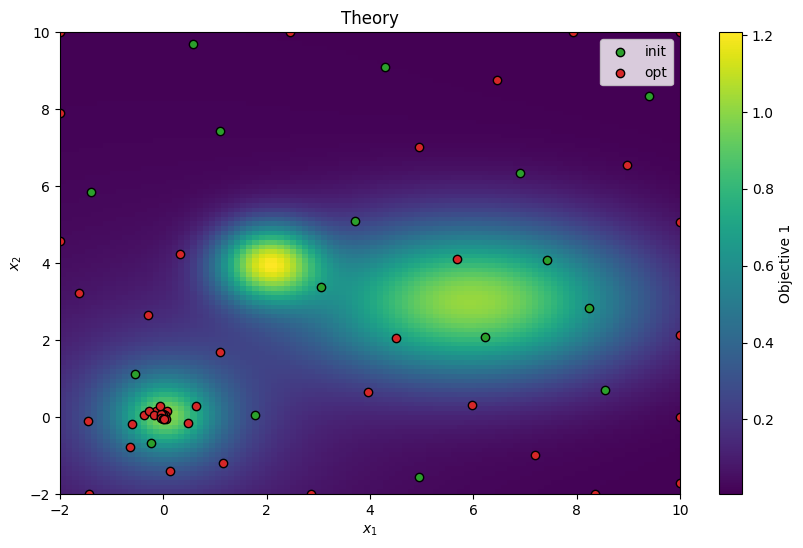

In [6]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

ext = (bounds[0, 0], bounds[1, 0], bounds[0, 1], bounds[1, 1])

# theory
th = ax1.imshow(
    obj1.T,
    aspect="auto",
    origin="lower",
    extent=ext
)
cbar = fig.colorbar(th, ax=ax1)
cbar.set_label("Objective 1")

ax1.scatter(ctx_init.X_physical[:, 0], ctx_init.X_physical[:, 1], color="tab:green", edgecolor="black", label="init")
ax1.scatter(ctx.X_opt[:, 0], ctx.X_opt[:, 1], color="tab:red", edgecolor="black", label="opt")

ax1.set_xlabel(r"$x_1$")
ax1.set_ylabel(r"$x_2$")
ax1.set_title("Theory")
ax1.legend()

## making the model

In [7]:
X_grid = torch.stack([X1, X2], dim=-1)
post_dict, mean_dict, std_dict = pa.get_posterior(x_physical=X_grid, step=None) # last posterior

mean = mean_dict["ElectronEnergyMean"]
std = std_dict["ElectronEnergyMean"]

Context created.
Observation added: x=[3.7012863159179688, 5.110287666320801], y=[-0.5300626754760742], shot_number=277
Observation added: x=[4.945160388946533, -1.5545367002487183], y=[0.001659519039094448], shot_number=278
Observation added: x=[9.408039093017578, 8.348128318786621], y=[-0.004231335129588842], shot_number=279
Observation added: x=[-0.5545055866241455, 1.1373066902160645], y=[0.4180881679058075], shot_number=280
Observation added: x=[0.5793428421020508, 9.690186500549316], y=[-0.13337568938732147], shot_number=281
Observation added: x=[8.24510383605957, 2.8419418334960938], y=[-0.001583153149113059], shot_number=282
Observation added: x=[6.90499210357666, 6.34543514251709], y=[-0.1379786878824234], shot_number=283
Observation added: x=[1.7705843448638916, 0.06950902938842773], y=[0.09203535318374634], shot_number=284
Observation added: x=[1.0950899124145508, 7.444915771484375], y=[-0.5974485278129578], shot_number=285
Observation added: x=[6.229145050048828, 2.09325504

## plot model

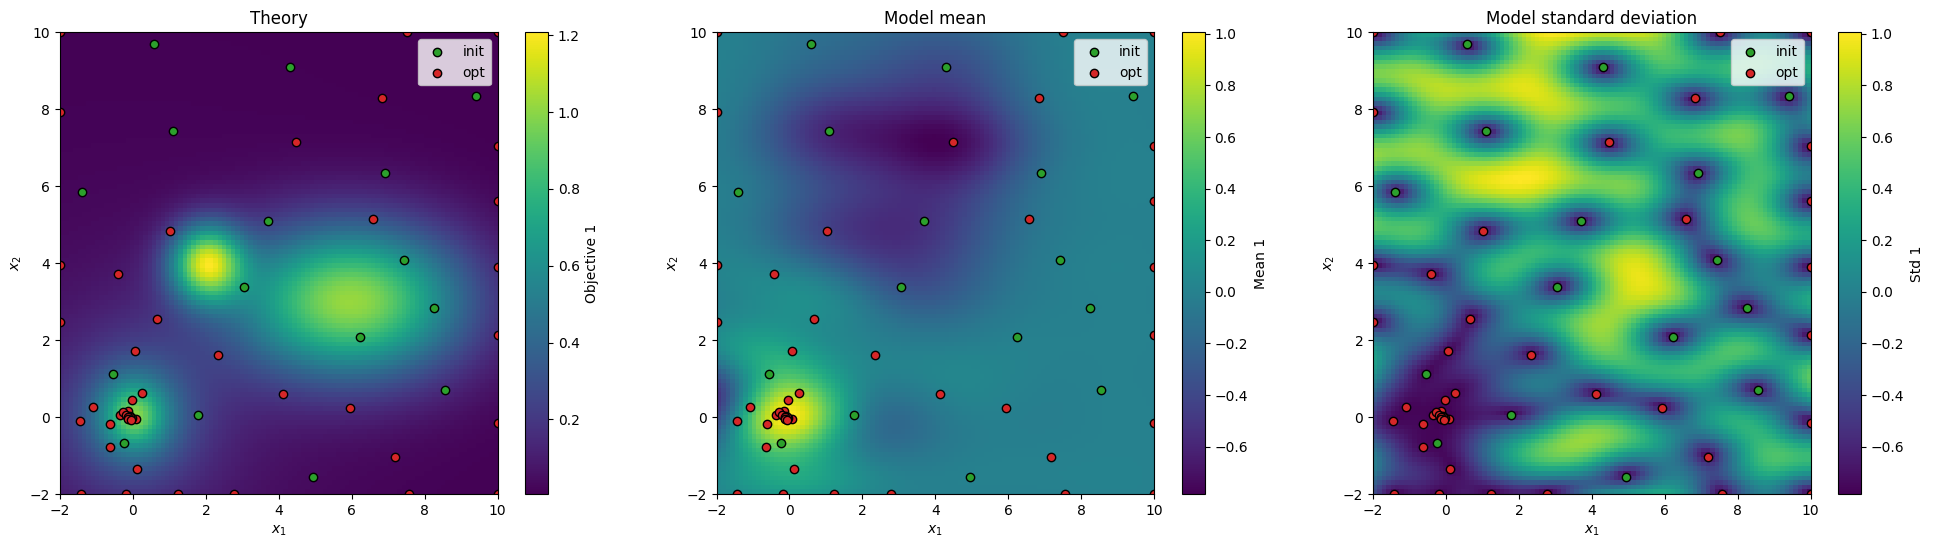

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

ext = (bounds[0, 0], bounds[1, 0], bounds[0, 1], bounds[1, 1])

### Theory
th = ax1.imshow(
    obj1.T,
    aspect="auto",
    origin="lower",
    extent=ext
)
cbar = fig.colorbar(th, ax=ax1)
cbar.set_label("Objective 1")

ax1.scatter(ctx_init.X_physical[:, 0], ctx_init.X_physical[:, 1], color="tab:green", edgecolor="black", label="init")
ax1.scatter(ctx.X_opt[:, 0], ctx.X_opt[:, 1], color="tab:red", edgecolor="black", label="opt")

ax1.set_xlabel(r"$x_1$")
ax1.set_ylabel(r"$x_2$")
ax1.set_title("Theory")
ax1.legend()


### Mean
me = ax2.imshow(
    mean.T, 
    origin="lower", 
    aspect="auto",
    extent=ext
)
cbar = fig.colorbar(me, ax=ax2)
cbar.set_label("Mean 1")

ax2.scatter(ctx_init.X_physical[:, 0], ctx_init.X_physical[:, 1], color="tab:green", edgecolor="black", label="init")
ax2.scatter(ctx.X_opt[:, 0], ctx.X_opt[:, 1], color="tab:red", edgecolor="black", label="opt")

ax2.set_xlabel(r"$x_1$")
ax2.set_ylabel(r"$x_2$")
ax2.set_title("Model mean")
ax2.legend()


### Std
st = ax3.imshow(
    std.T, 
    origin="lower", 
    aspect="auto",
    extent=ext
)
cbar = fig.colorbar(me, ax=ax3)
cbar.set_label("Std 1")

ax3.scatter(ctx_init.X_physical[:, 0], ctx_init.X_physical[:, 1], color="tab:green", edgecolor="black", label="init")
ax3.scatter(ctx.X_opt[:, 0], ctx.X_opt[:, 1], color="tab:red", edgecolor="black", label="opt")

ax3.set_xlabel(r"$x_1$")
ax3.set_ylabel(r"$x_2$")
ax3.set_title("Model standard deviation")
ax3.legend()
